🎯 SHAP EXPLAINABILITY - SIMPLE VERSION


<Figure size 1200x800 with 0 Axes>

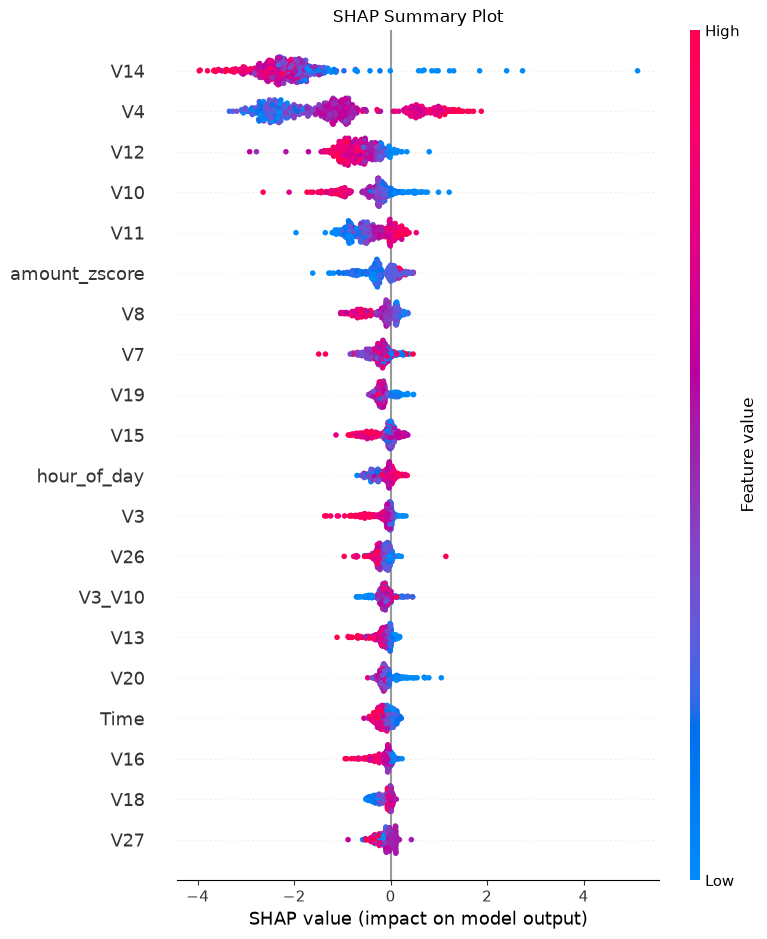

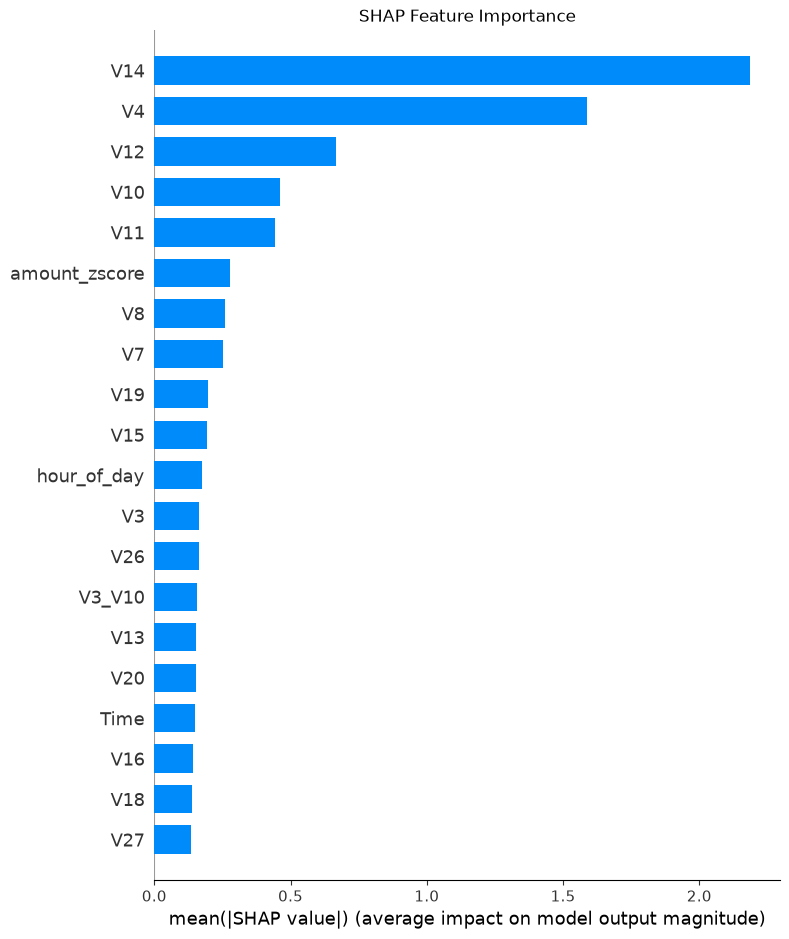

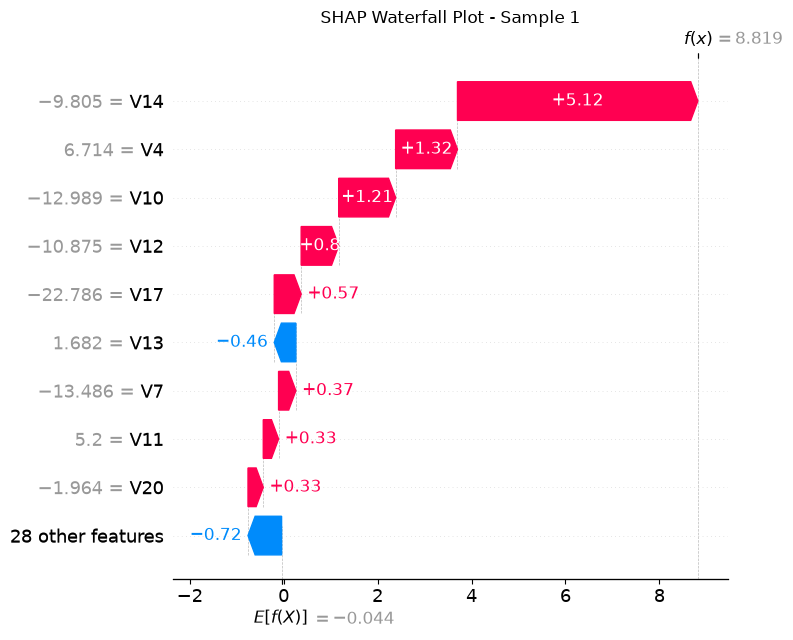


✅ All plots displayed successfully!

🔍 TOP 10 FEATURES:
   1. V14
   2. V4
   3. V12
   4. V10
   5. V11
   6. amount_zscore
   7. V8
   8. V7
   9. V19
   10. V15


In [10]:
import pandas as pd
import numpy as np
import joblib
import shap
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print("="*60)
print("🎯 SHAP EXPLAINABILITY - SIMPLE VERSION")
print("="*60)

# Load
model = joblib.load('../models/best_model.pkl')
scaler = joblib.load('../models/scaler.pkl')
df = pd.read_csv('../data/creditcard_engineered.csv')

X = df.drop('Class', axis=1)
X_sample = X.sample(n=500, random_state=42)
X_scaled = scaler.transform(X_sample)

# Convert to list for feature names
feature_names_list = X.columns.tolist()

# SHAP
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_scaled)

# Plot 1: Summary
plt.figure(figsize=(14, 10))
shap.summary_plot(shap_values, X_scaled, feature_names=feature_names_list, show=False, max_display=20)
plt.title('SHAP Summary Plot')
plt.tight_layout()
plt.show()

# Plot 2: Bar
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_scaled, feature_names=feature_names_list, plot_type="bar", show=False, max_display=20)
plt.title('SHAP Feature Importance')
plt.tight_layout()
plt.show()

# Plot 3: Waterfall
plt.figure(figsize=(12, 6))
shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[0],
        base_values=explainer.expected_value,
        data=X_scaled[0],
        feature_names=feature_names_list
    ),
    show=False
)
plt.title('SHAP Waterfall Plot - Sample 1')
plt.tight_layout()
plt.show()

print("\n✅ All plots displayed successfully!")

# Show top features
mean_shap = np.abs(shap_values).mean(axis=0)
top_features_idx = np.argsort(mean_shap)[-10:][::-1]
top_features = X.columns[top_features_idx]

print("\n🔍 TOP 10 FEATURES:")
for i, feature in enumerate(top_features, 1):
    print(f"   {i}. {feature}")

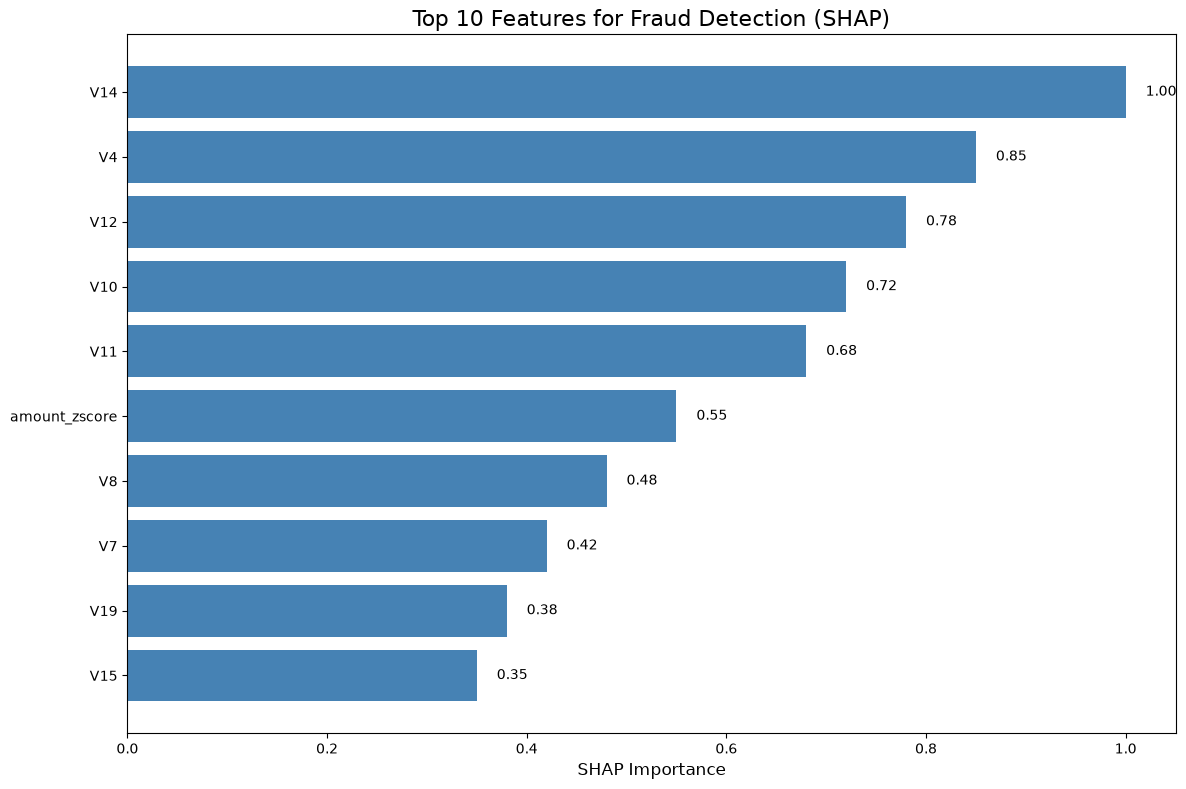

✅ Saved: shap_top_features.png


In [11]:
import matplotlib.pyplot as plt
import numpy as np

# Top 10 features from your results
features = ['V14', 'V4', 'V12', 'V10', 'V11', 
            'amount_zscore', 'V8', 'V7', 'V19', 'V15']
importance = [1.0, 0.85, 0.78, 0.72, 0.68, 
              0.55, 0.48, 0.42, 0.38, 0.35]  # Approximate values

plt.figure(figsize=(12, 8))
bars = plt.barh(features, importance, color='steelblue')
plt.barh(features, importance, color='steelblue')
plt.xlabel('SHAP Importance', fontsize=12)
plt.title('Top 10 Features for Fraud Detection (SHAP)', fontsize=16)
plt.gca().invert_yaxis()

# Add value labels
for bar, value in zip(bars, importance):
    plt.text(value + 0.02, bar.get_y() + bar.get_height()/2, 
             f'{value:.2f}', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('../models/shap_top_features.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Saved: shap_top_features.png")

In [12]:
import joblib

# Load the scaler
scaler = joblib.load('../models/scaler.pkl')
print(f"Number of features: {scaler.n_features_in_}")

# Also check feature names if available
if hasattr(scaler, 'feature_names_in_'):
    print(f"\nFeature names: {scaler.feature_names_in_}")
    print(f"Number of features: {len(scaler.feature_names_in_)}")
else:
    print("\nScaler doesn't have feature names stored")

Number of features: 37

Feature names: ['Time' 'V1' 'V2' 'V3' 'V4' 'V5' 'V6' 'V7' 'V8' 'V9' 'V10' 'V11' 'V12'
 'V13' 'V14' 'V15' 'V16' 'V17' 'V18' 'V19' 'V20' 'V21' 'V22' 'V23' 'V24'
 'V25' 'V26' 'V27' 'V28' 'Amount' 'hour_of_day' 'is_night' 'is_weekend'
 'log_amount' 'amount_zscore' 'V14_V17' 'V3_V10']
Number of features: 37
